In [1]:
#Cell 0: Install Required Packages

!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

In [2]:
#Cell 1: Imports

import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")
print(f"TensorFlow version: {tf.__version__}")


Imports successful.
TensorFlow version: 2.19.0


In [3]:
#Cell 2: Configuration Parameters

GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

IMG_SIZE = (224, 224)
BATCH_SIZE = 128
NUM_CLASSES = 4
EPOCHS_STAGE1 = 50  # First stage: frozen base model
EPOCHS_STAGE2 = 50  # Second stage: fine-tuning
TOTAL_EPOCHS = EPOCHS_STAGE1 + EPOCHS_STAGE2  # Total: 100 epochs

LEARNING_RATE_STAGE1 = 1e-4  # Initial learning rate
LEARNING_RATE_STAGE2 = 1e-5  # Lower LR for fine-tuning

SEED = 42
BEST_MODEL_SAVE_PATH = 'vgg19_tl_improved.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")
print(f"Total epochs: {TOTAL_EPOCHS} (Stage 1: {EPOCHS_STAGE1}, Stage 2: {EPOCHS_STAGE2})")


Configuration parameters set.
Total epochs: 100 (Stage 1: 50, Stage 2: 50)


In [4]:
#Cell 3: Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

print(f"Copying {GDRIVE_ZIP_PATH} to local storage...")
shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

if os.path.exists(LOCAL_UNZIP_DIR):
    shutil.rmtree(LOCAL_UNZIP_DIR)
os.makedirs(LOCAL_UNZIP_DIR)

print(f"Extracting {LOCAL_ZIP_PATH}...")
with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
    z.extractall(LOCAL_UNZIP_DIR)

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset successfully extracted.")
print(f"Data directory: {DATA_DIR}")
print(f"Contents: {os.listdir(DATA_DIR)}")


Mounted at /content/drive
Copying /content/drive/MyDrive/AD_Dataset_compressed.zip to local storage...
Extracting /content/Data.zip...
Dataset successfully extracted.
Data directory: /content/Data/AD Datasets/Data
Contents: ['Non Demented', 'Mild Dementia', 'Very mild Dementia', 'Moderate Dementia']


In [5]:
#Cell 4: Load Dataset & Split (80/10/10)

full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes found:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

# Ensure at least 1 batch for val and test
if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"\nDataset splits:")
print(f"Total batches: {total_batches}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")


Found 86437 files belonging to 4 classes.
Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Dataset splits:
Total batches: 676
Training batches: 540
Validation batches: 67
Test batches: 69


In [6]:
#Cell 5: Calculate Class Weights & Enhanced Data Augmentation

# Calculate class weights for handling imbalance
train_label_list = []
for _, lbl in train_dataset:
    train_label_list.extend(lbl.numpy())
train_label_array = np.array(train_label_list)

unique_classes = np.unique(train_label_array)
weights = compute_class_weight('balanced', classes=unique_classes, y=train_label_array)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, weights)}
print("Class weights:", class_weight_dict)
print(f"Class mapping: {dict(zip(unique_classes, class_names))}")

# Enhanced Data Augmentation for Medical Imaging
# Includes brightness, contrast, and noise simulation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),  # Slight rotation for anatomical variations
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),  # Medical imaging brightness variation
    tf.keras.layers.RandomContrast(0.2),    # Medical imaging contrast variation
])

# Apply Gaussian noise function (simulate MRI quality variations)
def add_gaussian_noise(image, label):
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    noisy_image = tf.clip_by_value(image + noise, 0.0, 1.0)
    return noisy_image, label

# Create augmented dataset
train_dataset_aug = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y),
                                       num_parallel_calls=AUTOTUNE)
train_dataset_aug = train_dataset_aug.map(add_gaussian_noise, num_parallel_calls=AUTOTUNE)

# Cache and prefetch for performance
train_dataset_aug = train_dataset_aug.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\nEnhanced augmentation configured:")
print("- Random horizontal flip")
print("- Random rotation (±15 degrees)")
print("- Random zoom")
print("- Random brightness variation")
print("- Random contrast variation")
print("- Gaussian noise (σ=0.05)")
print("\nDatasets cached and prefetched for optimal performance.")


Class weights: {0: 4.3680485338725985, 1: 45.23560209424084, 2: 0.32106426859404325, 3: 1.5764984946628957}
Class mapping: {np.int32(0): 'Mild Dementia', np.int32(1): 'Moderate Dementia', np.int32(2): 'Non Demented', np.int32(3): 'Very mild Dementia'}

Enhanced augmentation configured:
- Random horizontal flip
- Random rotation (±15 degrees)
- Random zoom
- Random brightness variation
- Random contrast variation
- Gaussian noise (σ=0.05)

Datasets cached and prefetched for optimal performance.


In [7]:
#Cell 6: Define Focal Loss Function

def focal_loss_fn(alpha=0.25, gamma=2.5):
    """
    Focal Loss for handling class imbalance.
    Focuses learning on hard examples.

    Args:
        alpha: Weighting factor for rare class (default: 0.25)
        gamma: Focusing parameter (default: 2.5)

    Returns:
        Focal loss function
    """
    def focal_loss(y_true, y_pred):
        # Convert sparse labels to one-hot encoding
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        # Clip predictions to avoid numerical instability
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Calculate weighting factor (focus on hard examples)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        # Calculate focal loss
        loss = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
    return focal_loss

print("Focal Loss function defined (alpha=0.25, gamma=2.5)")


Focal Loss function defined (alpha=0.25, gamma=2.5)


In [8]:
#Cell 7: Build Transfer Learning Model with VGG19

# Load pre-trained VGG19 (ImageNet weights)
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Stage 1: Freeze base model (for transfer learning)
base_model.trainable = False
print(f"Base model frozen. Trainable parameters: {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

# Build model with enhanced head architecture
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg19.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)

# Enhanced head architecture (similar to ResNet50)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 2, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 4, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 2, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(10, activation='relu')(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

print("\nModel Summary:")
model.summary()

total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model frozen. Trainable parameters: 0

Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │    525,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2048)      │  2,099,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4096)      │  8,392,704 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4096)      │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2048)      │  8,390,656 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024)      │  2,098,176 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024)      │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    262,400 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]   

 Total params: 41,795,446 (159.44 MB)

 Trainable params: 21,771,062 (83.05 MB)

 Non-trainable params: 20,024,384 (76.39 MB)


Total parameters: 41,795,446
Trainable parameters: 21,771,062
Non-trainable parameters: 20,024,384


In [9]:
#Cell 8: Stage 1 Training - Frozen Base Model

print("=" * 80)
print("STAGE 1: Training with FROZEN base model (Transfer Learning)")
print("=" * 80)

# Compile model for Stage 1
optimizer = Adam(learning_rate=LEARNING_RATE_STAGE1)
model.compile(
    optimizer=optimizer,
    loss=focal_loss_fn(alpha=0.25, gamma=2.5),
    metrics=['accuracy']
)

# Callbacks for Stage 1
checkpoint_stage1 = ModelCheckpoint(
    filepath='vgg19_stage1_best.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Learning Rate Scheduler - Reduce on plateau
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Early stopping (will restore best weights)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print(f"\nStarting Stage 1 training ({EPOCHS_STAGE1} epochs)...")
print(f"Initial Learning Rate: {LEARNING_RATE_STAGE1}")
print(f"Base model: FROZEN")

# Train Stage 1
history_stage1 = model.fit(
    train_dataset_aug,
    epochs=EPOCHS_STAGE1,
    validation_data=val_dataset,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_stage1, lr_scheduler],
    verbose=1
)

print("\nStage 1 training complete!")
print(f"Best validation loss: {min(history_stage1.history['val_loss']):.4f}")
print(f"Best validation accuracy: {max(history_stage1.history['val_accuracy']):.4f}")


STAGE 1: Training with FROZEN base model (Transfer Learning)

Starting Stage 1 training (50 epochs)...
Initial Learning Rate: 0.0001
Base model: FROZEN
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7721 - loss: 0.0699
Epoch 1: val_loss improved from inf to 0.16301, saving model to vgg19_stage1_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 170s 285ms/step - accuracy: 0.7721 - loss: 0.0699 - val_accuracy: 0.7695 - val_loss: 0.1630 - learning_rate: 1.0000e-04
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7807 - loss: 0.0648
Epoch 2: val_loss improved from 0.16301 to 0.11203, saving model to vgg19_stage1_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 62s 114ms/step - accuracy: 0.7807 - loss: 0.0648 - val_accuracy: 0.7695 - val_loss: 0.1120 - learning_rate: 1.0000e-04
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7807 - loss: 0.0641
Epoch 3: val_loss did not improve from 0.11203
540/540 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.78

In [15]:
#Cell 9: Stage 2 Fine-Tuning - Unfreeze Last Layers

print("=" * 80)
print("STAGE 2: Fine-tuning with UNFROZEN last layers")
print("=" * 80)

# --- LOAD BEST WEIGHTS FROM STAGE 1 ---
# This ensures we start from the best checkpoint of Stage 1, not the last epoch.
try:
    print("Loading best weights from Stage 1...")
    model.load_weights('vgg19_stage1_best.keras')
    print("Weights loaded successfully.")
except Exception as e:
    print(f"Could not load weights (starting from current memory state): {e}")
# --------------------------------------

# Unfreeze the last blocks of VGG19 for fine-tuning
base_model.trainable = True

# Freeze early layers, unfreeze later layers (Block 4 and 5)
for layer in base_model.layers:
    if 'block5' in layer.name or 'block4' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Count trainable parameters
trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters after unfreezing: {trainable_count:,}")

# Recompile with lower learning rate for fine-tuning
optimizer_finetune = Adam(learning_rate=LEARNING_RATE_STAGE2)
model.compile(
    optimizer=optimizer_finetune,
    loss=focal_loss_fn(alpha=0.25, gamma=2.5),
    metrics=['accuracy']
)

print(f"Fine-tuning learning rate: {LEARNING_RATE_STAGE2}")

# Callbacks for Stage 2
checkpoint_stage2 = ModelCheckpoint(
    filepath=BEST_MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

lr_scheduler_stage2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,  # More aggressive reduction for fine-tuning
    patience=5,
    min_lr=1e-8,
    verbose=1
)

early_stop_stage2 = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

print(f"\nStarting Stage 2 fine-tuning ({EPOCHS_STAGE2} epochs)...")

# Train Stage 2
# Note: Removed initial_epoch to simplify counter (will run 1->50)
history_stage2 = model.fit(
    train_dataset_aug,
    epochs=EPOCHS_STAGE2,
    validation_data=val_dataset,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_stage2, lr_scheduler_stage2, early_stop_stage2],
    verbose=1
)

print("\nStage 2 fine-tuning complete!")
print(f"Best validation loss: {min(history_stage2.history['val_loss']):.4f}")
print(f"Best validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")

STAGE 2: Fine-tuning with UNFROZEN last layers
Loading best weights from Stage 1...
Weights loaded successfully.
Trainable parameters after unfreezing: 39,469,878
Fine-tuning learning rate: 1e-05

Starting Stage 2 fine-tuning (50 epochs)...
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7807 - loss: 0.0636
Epoch 1: val_loss improved from inf to 0.10910, saving model to vgg19_tl_improved.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.7807 - loss: 0.0636 - val_accuracy: 0.7695 - val_loss: 0.1091 - learning_rate: 1.0000e-05
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7807 - loss: 0.0628
Epoch 2: val_loss did not improve from 0.10910
540/540 ━━━━━━━━━━━━━━━━━━━━ 74s 137ms/step - accuracy: 0.7807 - loss: 0.0628 - val_accuracy: 0.7695 - val_loss: 0.2005 - learning_rate: 1.0000e-05
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7807 - loss: 0.0626
Epoch 3: val_loss improved from 0.10910 to 0.07031, saving model

In [16]:
#Cell 10: Combine Training Histories

# Combine histories from both stages
combined_history = {
    'loss': history_stage1.history['loss'] + history_stage2.history['loss'],
    'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss'],
    'accuracy': history_stage1.history['accuracy'] + history_stage2.history['accuracy'],
    'val_accuracy': history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy'],
    'lr': history_stage1.history.get('lr', []) + history_stage2.history.get('lr', [])
}

print("Training histories combined.")
print(f"Total epochs: {len(combined_history['loss'])}")


Training histories combined.
Total epochs: 41


In [17]:
#Cell 11: Load Best Model and Evaluate

print("=" * 80)
print("FINAL EVALUATION")
print("=" * 80)

# Load the best model from Stage 2
best_model = tf.keras.models.load_model(
    BEST_MODEL_SAVE_PATH,
    custom_objects={'focal_loss': focal_loss_fn(alpha=0.25, gamma=2.5)}
)

print(f"Loaded best model from: {BEST_MODEL_SAVE_PATH}")

# Evaluate on all datasets
print("\nEvaluating on training set...")
train_loss, train_acc = best_model.evaluate(train_dataset, verbose=0)

print("Evaluating on validation set...")
val_loss, val_acc = best_model.evaluate(val_dataset, verbose=0)

print("Evaluating on test set...")
test_loss, test_acc = best_model.evaluate(test_dataset, verbose=0)

print("\n" + "=" * 80)
print("OVERALL PERFORMANCE")
print("=" * 80)
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nTraining Loss:   {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss:       {test_loss:.4f}")


FINAL EVALUATION
Loaded best model from: vgg19_tl_improved.keras

Evaluating on training set...
Evaluating on validation set...
Evaluating on test set...

OVERALL PERFORMANCE
Training Accuracy:   0.7788 (77.88%)
Validation Accuracy: 0.7695 (76.95%)
Test Accuracy:       0.7775 (77.75%)

Training Loss:   0.0570
Validation Loss: 0.0603
Test Loss:       0.0600


In [18]:
#Cell 12: Early Detection Focused Evaluation

print("\n" + "=" * 80)
print("EARLY DETECTION METRICS (Per-Class Performance)")
print("=" * 80)

# Get predictions
y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)
y_pred_probs = best_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Calculate key metrics for early detection
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

print("\n" + "=" * 80)
print("EARLY DETECTION KEY METRICS")
print("=" * 80)

# Find index for "Very mild Dementia" (early stage)
early_stage_idx = None
for i, name in enumerate(class_names):
    if 'Very mild' in name or 'very mild' in name:
        early_stage_idx = i
        break

if early_stage_idx is not None:
    early_stage_name = class_names[early_stage_idx]
    print(f"\n{early_stage_name} (Early Stage) Metrics:")
    print(f"  Precision: {precision[early_stage_idx]:.4f}")
    print(f"  Recall:    {recall[early_stage_idx]:.4f} (Most important for early detection)")
    print(f"  F1-Score:  {f1[early_stage_idx]:.4f}")
    print(f"  Support:   {support[early_stage_idx]}")

# Calculate macro and weighted averages
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"  Macro F1-Score: {macro_f1:.4f} (Balanced across all classes)")
print(f"  Weighted F1-Score: {weighted_f1:.4f} (Weighted by support)")

# Early stage sensitivity (combining Very Mild + Mild)
mild_idx = None
for i, name in enumerate(class_names):
    if 'Mild' in name and 'Very' not in name:
        mild_idx = i
        break

if early_stage_idx is not None and mild_idx is not None:
    early_stages_mask = (y_true == early_stage_idx) | (y_true == mild_idx)
    early_stages_true = y_true[early_stages_mask]
    early_stages_pred = y_pred[early_stages_mask]

    if len(early_stages_true) > 0:
        early_sensitivity = recall_score(early_stages_true, early_stages_pred,
                                          labels=[early_stage_idx, mild_idx],
                                          average='weighted')
        print(f"\nEarly Stage Sensitivity (Very Mild + Mild): {early_sensitivity:.4f}")



EARLY DETECTION METRICS (Per-Class Performance)

Detailed Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.0000    0.0000    0.0000       529
 Moderate Dementia     0.0000    0.0000    0.0000        55
      Non Demented     0.7775    1.0000    0.8748      6796
Very mild Dementia     0.0000    0.0000    0.0000      1361

          accuracy                         0.7775      8741
         macro avg     0.1944    0.2500    0.2187      8741
      weighted avg     0.6045    0.7775    0.6802      8741


EARLY DETECTION KEY METRICS

Very mild Dementia (Early Stage) Metrics:
  Precision: 0.0000
  Recall:    0.0000 (Most important for early detection)
  F1-Score:  0.0000
  Support:   1361

Overall Metrics:
  Macro F1-Score: 0.2187 (Balanced across all classes)
  Weighted F1-Score: 0.6802 (Weighted by support)

Early Stage Sensitivity (Very Mild + Mild): 0.0000


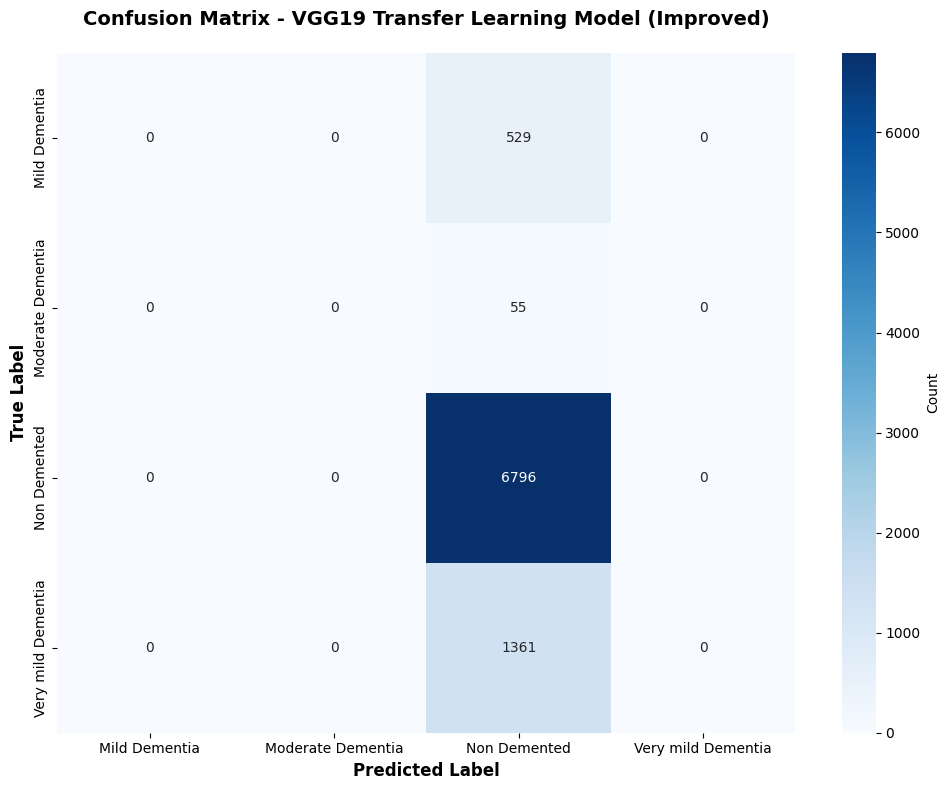

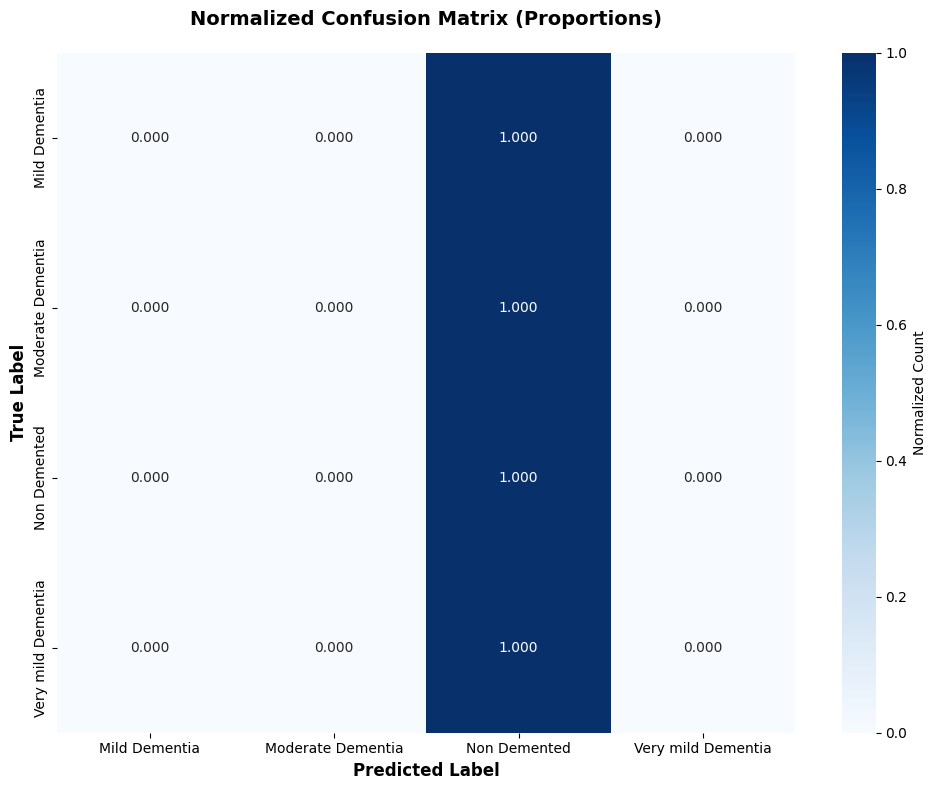

Confusion matrices plotted.


In [19]:
#Cell 13: Confusion Matrix Visualization

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG19 Transfer Learning Model (Improved)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Normalized Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix (Proportions)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Confusion matrices plotted.")


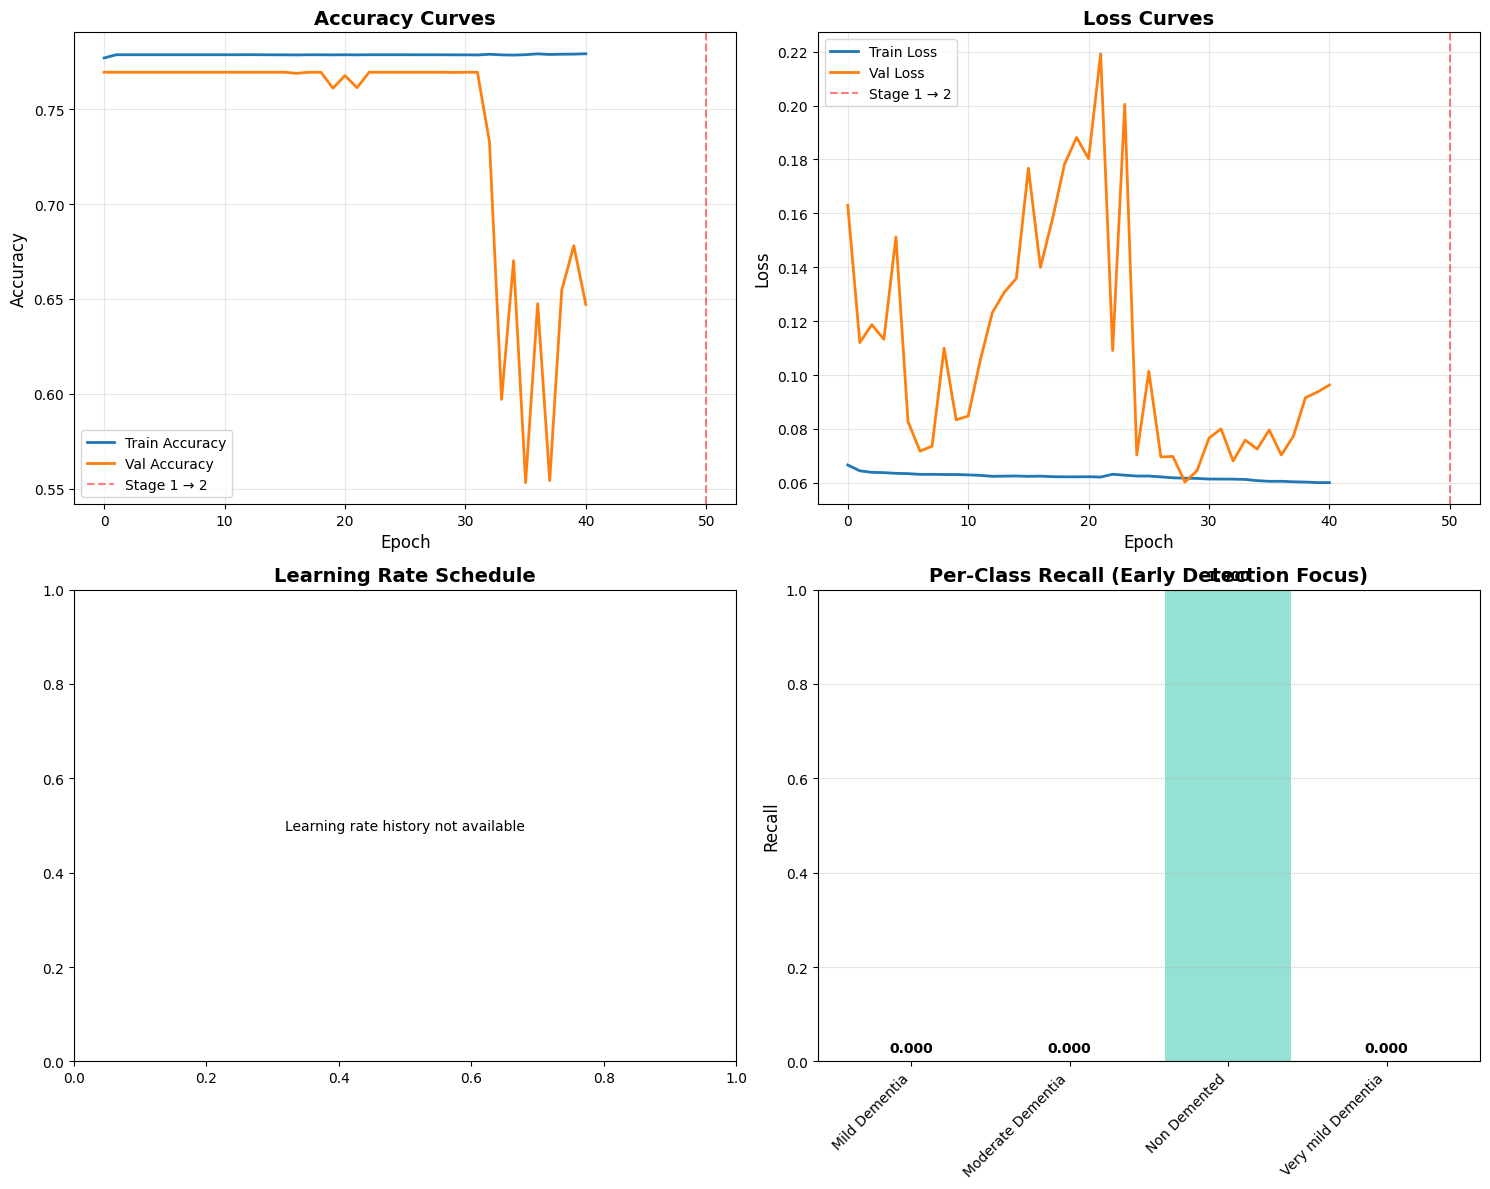

Training curves and metrics visualization complete.


In [20]:
#Cell 14: Training Curves Visualization

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy curves
axes[0, 0].plot(combined_history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(combined_history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 0].axvline(x=EPOCHS_STAGE1, color='r', linestyle='--', alpha=0.5, label='Stage 1 → 2')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss curves
axes[0, 1].plot(combined_history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(combined_history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 1].axvline(x=EPOCHS_STAGE1, color='r', linestyle='--', alpha=0.5, label='Stage 1 → 2')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate (if available)
if 'lr' in combined_history and len(combined_history['lr']) > 0:
    axes[1, 0].plot(combined_history['lr'], label='Learning Rate', linewidth=2, color='green')
    axes[1, 0].axvline(x=EPOCHS_STAGE1, color='r', linestyle='--', alpha=0.5, label='Stage 1 → 2')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Learning rate history not available',
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')

# Per-class recall (for early detection focus)
class_recalls = []
for i, name in enumerate(class_names):
    if i < len(recall):
        class_recalls.append(recall[i])

axes[1, 1].bar(range(len(class_names)), class_recalls, color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
axes[1, 1].set_xticks(range(len(class_names)))
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Per-Class Recall (Early Detection Focus)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(class_recalls):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Training curves and metrics visualization complete.")


In [22]:
#Cell 15: Save Model and Summary

# Save final model
model.save('/content/drive/MyDrive/vgg19_tl_improved_final.keras')
print("Model saved to Google Drive.")

# Calculate the recall for early stage (handle None case safely)
if early_stage_idx is not None:
    early_stage_recall = f"{recall[early_stage_idx]:.4f}"
else:
    early_stage_recall = "N/A"

# Save summary to file
summary_text = f"""
================================================================================
TRANSFER LEARNING MODEL - VGG19 IMPROVED VERSION
================================================================================

Configuration:
- Architecture: VGG19 (ImageNet pretrained)
- Training Strategy: Two-stage fine-tuning
  * Stage 1: Frozen base (50 epochs)
  * Stage 2: Fine-tuned last layers (50 epochs)
- Total Epochs: {TOTAL_EPOCHS}
- Learning Rates: Stage 1={LEARNING_RATE_STAGE1}, Stage 2={LEARNING_RATE_STAGE2}
- Batch Size: {BATCH_SIZE}
- Image Size: {IMG_SIZE}

Enhanced Features:
- Enhanced data augmentation (brightness, contrast, noise)
- Learning rate scheduling (ReduceLROnPlateau)
- Focal Loss for class imbalance handling
- Two-stage fine-tuning strategy

Results:
- Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)
- Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)
- Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)

Per-Class Performance:
{classification_report(y_true, y_pred, target_names=class_names, digits=4)}

Key Metrics:
- Macro F1-Score: {macro_f1:.4f}
- Weighted F1-Score: {weighted_f1:.4f}

Early Detection Focus:
- Very Mild Dementia Recall: {early_stage_recall}
"""

print(summary_text)

# Save to file
with open('vgg19_training_summary.txt', 'w') as f:
    f.write(summary_text)

print("\nSummary saved to vgg19_training_summary.txt")
print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)

Model saved to Google Drive.

TRANSFER LEARNING MODEL - VGG19 IMPROVED VERSION

Configuration:
- Architecture: VGG19 (ImageNet pretrained)
- Training Strategy: Two-stage fine-tuning
  * Stage 1: Frozen base (50 epochs)
  * Stage 2: Fine-tuned last layers (50 epochs)
- Total Epochs: 100
- Learning Rates: Stage 1=0.0001, Stage 2=1e-05
- Batch Size: 128
- Image Size: (224, 224)

Enhanced Features:
- Enhanced data augmentation (brightness, contrast, noise)
- Learning rate scheduling (ReduceLROnPlateau)
- Focal Loss for class imbalance handling
- Two-stage fine-tuning strategy

Results:
- Training Accuracy:   0.7788 (77.88%)
- Validation Accuracy: 0.7695 (76.95%)
- Test Accuracy:       0.7775 (77.75%)

Per-Class Performance:
                    precision    recall  f1-score   support

     Mild Dementia     0.0000    0.0000    0.0000       529
 Moderate Dementia     0.0000    0.0000    0.0000        55
      Non Demented     0.7775    1.0000    0.8748      6796
Very mild Dementia     0.0000